# 二項ロジスティック回帰による異常検知

工業製品のロットあたりの不良品数や時間あたりの故障発生数のように、ある基準あたりの発生回数$y$としてデータが取得される計数データの異常検知を考えます。

このとき、不良率が製品のサイズに依存する、また故障発生率が気温に依存するように、**発生確率**$\mu$**が他の変数**$\boldsymbol{x}$**に応じて変化する**ケースは少なくありません。このようなケースには、**計数データ向けの統計モデリング手法**を用いることで、**発生確率の変化に正常範囲を柔軟に連動**させた高精度な異常検知が可能となります。

計数データ向けの統計モデルの中でもよく用いられるのが、**二項ロジスティック回帰**（binomial logistic regression）と**ポアソン回帰**（Poisson regression）です。両者は以下のように使い分けられます。

|手法名|モデルの確率分布|リンク関数|モデリング対象の現象|分母にあたる変数|
|---|---|---|---|---|
|二項ロジスティック回帰|二項分布|ロジット関数|$n$回試行した際の発生数y|試行数n（離散型）|
|ポアソン回帰|ポアソン分布|対数関数面積・時間$t$あたりの発生数$y$|観測区間t（連続型）|

ここでは二項ロジスティック回帰モデルによる異常検知を、Python（PyMCによるベイズ統計モデリング）を用いて以下の手順で実装する方法を解説します。

- A. 変数の選択
- B. モデルの学習
- C. 推論

なおデータセットには5.3節でも使用したバスケットボールのスリーポイントシュート成功率のデータを、ターゲットとする誤報率としては0.0027を採用します（最尤推定による多変数線形回帰モデルと同様）。

使用するデータの例を以下に再掲します。

```csv
PLAYER_ID,AGE,FG3M,FG3A
203932,23.0,121,347
1628988,22.0,43,127
1627846,25.0,32,100
201143,33.0,73,203
202329,28.0,96,280
:
```

`PLAYER_ID`列が各選手を表すID、`AGE`列が年齢、`FG3A`列がスリーポイントシュート試投数$n$、`FG3M`列が成功数$x$を表しており、2022年度のデータを学習用、2023年度のデータを推論用として用います。

### 変数の選択

説明変数候補の中から、成功確率（発生率）$\mu$に寄与する変数のみを選択します

今回使用するデータでは、説明変数候補として使用できるのは`AGE`のみのため、この変数が成功率$\mu$に寄与するかを分析するため、見かけの成功率（`FG3M`を`FG3A`で割ったもの）と一緒にプロットします。

<Axes: xlabel='AGE', ylabel='FG3_PCT'>

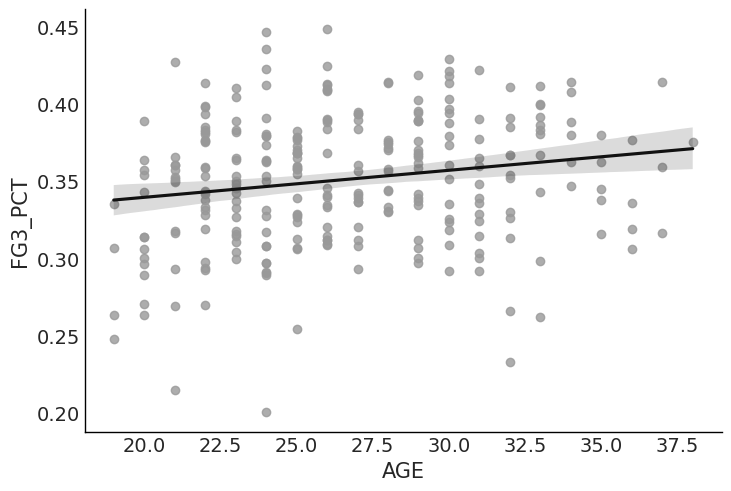

In [82]:
# 年齢AGEと3ポイントシュート成功率の関係をプロット
import pandas as pd
import seaborn as sns

# 3ポイントシュート成功率データ
df_train = pd.read_csv('./datasets/player_stats_2022.csv')
df_train = df_train[['PLAYER_NAME', 'AGE', 'FG3M', 'FG3A']]
df_3p_over100 = df_train[df_train['FG3A'] > 100].copy()  # 試投数100以上の選手に絞る
df_3p_over100['FG3_PCT'] = df_3p_over100['FG3M'] / df_3p_over100['FG3A']  # 見かけの成功率を計算
sns.regplot(df_3p_over100, x="AGE", y="FG3_PCT",
            scatter_kws={'color':'#999999'}, line_kws={'color':'#111111'})

横軸が`AGE`（年齢）、縦軸`FG3_PCT`が見かけの成功率（`FG3M`を`FG3A`で割ったもの）を表しています。図からは、年齢が高い選手ほど成功率が上がる傾向が読み取れます。

過去3年間のデータにおいても同様の傾向があるかを確認してみます。

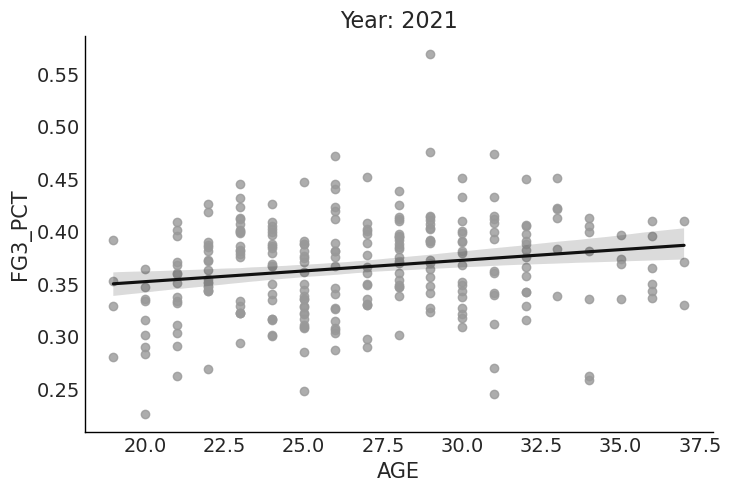

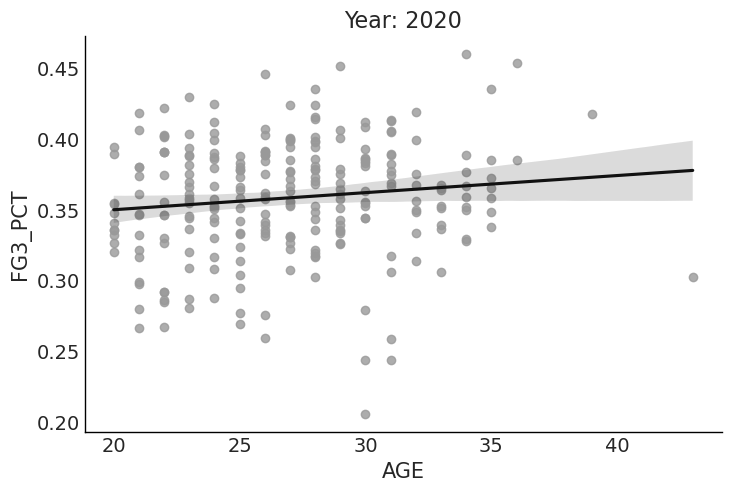

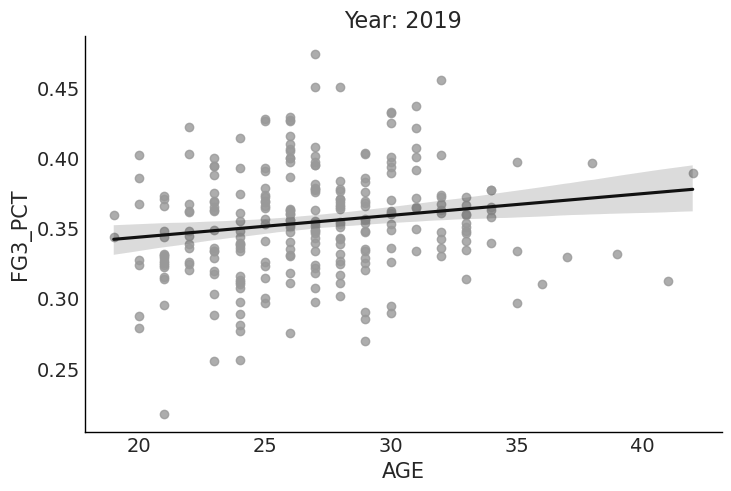

In [83]:
# 年齢AGEと3ポイントシュート成功率の関係をプロット（過去3年分）
import matplotlib.pyplot as plt

years = [2021, 2020, 2019]

for year in years:
    df_train = pd.read_csv(f'./datasets/player_stats_{year}.csv')
    df_train = df_train[['PLAYER_NAME', 'AGE', 'FG3M', 'FG3A']]
    df_3p_over100 = df_train[df_train['FG3A'] > 100].copy()  # 試投数100以上の選手に絞る
    df_3p_over100['FG3_PCT'] = df_3p_over100['FG3M'] / df_3p_over100['FG3A']  # 見かけの成功率を計算
    sns.regplot(df_3p_over100, x="AGE", y="FG3_PCT",
                scatter_kws={'color':'#999999'}, line_kws={'color':'#111111'})
    plt.title(f'Year: {year}')
    plt.show()

いずれの年も、年齢が高い選手ほど成功率が上がる傾向が見られ、年齢と成功率には相関があるとみなせそうです。

この相関を反映させるため、年齢を説明変数$x$、スリーポイントシュートの試投数（試行数）を$n$、成功数を$y$として以下のような二項ロジスティック回帰モデルを構築します。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\eta=w_1 x+w_0  \nonumber \\
&\rm{logit}(\mu)=\eta  \nonumber \\
&p(y \mid n, x, w_1, w_0) = Bi(n,\mu)
\end{align}
" />

なお、年齢が高いほど成功率が上がる理由は明確ではありませんが、例えば以下のような仮説が考えられます。

- 年齢による身体能力の衰えを、シュートの精度でカバーしている
- スリーポイントシュート能力の高い選手ほどリーグで長く生き残れる

## B. モデルの学習

ベイズ線形回帰のケースと同様、以下の4ステップに分けてMCMC（PyMC）を用いた二項ロジスティック回帰モデルの学習法（MCMCサンプリングの方法）を解説します。

- I. MCMCの実行
- II. 収束の確認
- III. 学習データからしきい値を計算
- IV. MCMC サンプルを保存

### I. MCMCの実行

まずデータの読み込みと前処理を行います。

In [84]:
# コード8.12 データの読み込みと前処理
import pandas as pd

###### 学習データの読み込みと前処理######
# スリーポイントシュート成功率データ
df_train = pd.read_csv('./datasets/player_stats_2022.csv')
df_train = df_train[df_train['FG3A'] > 0] # 試投数0を除外
# 学習データの説明変数x、応答変数y、試行数nを別々に保持してndarray化
x_train = df_train['AGE'].to_numpy()
y_train = df_train['FG3M'].to_numpy()
n_train = df_train['FG3A'].to_numpy()

次にモデル式を記述し、MCMCを実行します。線形回帰モデルの場合と同様、pm.Model クラス内に事前分布、線形予測子、確率分布を記述します。
また線形回帰モデルでは記述しなかったリンク関数に関しても、その逆関数（シグモイド関数`pm.math.invlogit`）を明記する必要があります。

In [85]:
# コード8.13 MCMC による二項ロジスティック回帰モデルのパラメータ推定
import pymc as pm

###### 学習ステップ1. 正常のモデルを作成する######
seed=42 # 乱数シードを指定（結果の再現性を担保）
# モデル定義用のインスタンスを作成
binomial_regression_model = pm.Model()
# モデル式を記述
with binomial_regression_model:
    # 説明変数xと試行数nを観測値として定義
    x = pm.Data("x", x_train, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w_1 = pm.Normal("w_1", mu=0, sigma=100)
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0 + w_1*x
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")

# MCMCの実行（学習）
with binomial_regression_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0, w_1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


<xarray.Dataset> Size: 72kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    w_0      (chain, draw) float64 32kB -0.7306 -0.7518 ... -0.8454 -0.7516
    w_1      (chain, draw) float64 32kB 0.0049 0.005285 ... 0.008898 0.005553
Attributes:
    created_at:                 2025-10-31T06:02:10.031406+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              3.3184211254119873
    tuning_steps:               1000

`pm.model_to_graphviz`関数を用いてグラフィカルモデルを可視化します。

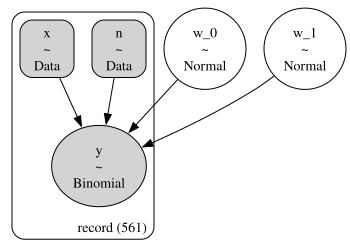

In [86]:
pm.model_to_graphviz(binomial_regression_model)

書籍本文の図8.13と同様のモデルが定義できていることがわかります。

### II. 収束の確認

[ArviZ](https://www.arviz.org/en/latest/)の`az.plot_trace`関数で事後分布とトレースプロットをプロットし、`az.summary`関数でMCMCサンプルの概要を表示します。

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w_0,-0.792,0.044,-0.876,-0.712,0.002,0.002,762.875,555.774,1.004
w_1,0.007,0.002,0.004,0.010,0.000,0.000,752.236,538.105,1.004


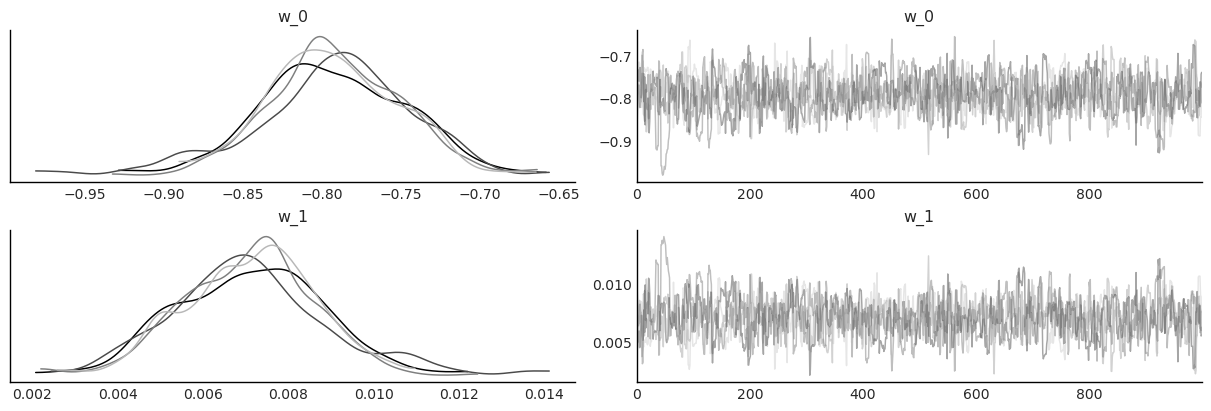

In [87]:
# コード8.15 トレースプロットとr_hat による収束の確認
import arviz as az

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3)

パラメータ`w_0`、`w_1`ともに、各チェーンの事後分布の形状がほぼ等しくなっており、`r_hat`が1に非常に近い値となっているため、収束していると判断できそうです（`ess_bulk`も400以上となっており、MCMCのサンプルサイズも足りていそう）。

また、年齢xに対する切片である`w_1`の`hdi_3%`（下側の3%信用区間）が0.004となっており、統計検定の観点からは、切片が0よりも有意に⼤きいとみなせそうです。よって「年齢が上がるほどスリーポイントシュート成功率が上がる」という仮定が、統計的に裏付けられていることがわかります。

この傾向を可視化するため、横軸に説明変数$x$（年齢`AGE`）をとって成功率パラメータ$\mu$の事後分布（$w_0$、$w_1$のMCMCサンプル$w_0^{(t)}$、$w_1^{(t)}$を用いて$w_1^{(t)}x+w_0^{(t)}$からMCMCサンプルを求める）をプロットしてみます。

<Axes: xlabel='AGE (x)', ylabel='$\\mu$'>

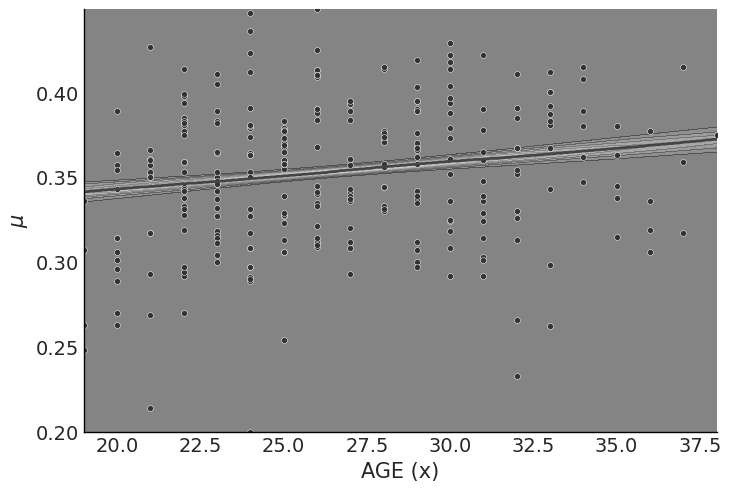

In [88]:
# 年齢xと成功率μの事後分布の関係を可視化
import matplotlib.cm as cm
import xarray as xr
from scipy import stats
import numpy as np

# 学習データから試投数100以上のみを抽出し、xとmu範囲を決定
df_train_a100over = df_train[df_train['FG3A'] > 100]
x_min, x_max = df_train_a100over['AGE'].min(), df_train_a100over['AGE'].max()
mu_min, mu_max = df_train_a100over['FG3_PCT'].min(), df_train_a100over['FG3_PCT'].max()
# (x,μ)格子点を作成
x_grid = np.linspace(x_min, x_max, num=200)
mu_grid = np.linspace(mu_min, mu_max, num=800)
X, MU = np.meshgrid(x_grid, mu_grid)
# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = trace.posterior["w_0"] + trace.posterior["w_1"]*xr.DataArray(x_grid, dims=["record"])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = 1 / (1+np.exp(-rho_posterior))
# xの値ごとにmuの事後分布の確率密度関数を計算
pdf_all_grid = []
map_grid = []  # MAP推定値
for x_idx, x_i in enumerate(x_grid):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # KDEでmuの事後分布分布の確率密度関数を計算
    kernel = stats.gaussian_kde(mu_posterior_i.ravel())
    pdf_i = kernel(mu_grid)  # 確率密度
    map_i = mu_grid[np.argmax(pdf_i)]
    # データを保持
    pdf_all_grid.append(pdf_i)
    map_grid.append(map_i)
pdf_grid_pivot = np.array(pdf_all_grid).T
# 確率密度をプロット
plt.contourf(X, MU, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)
plt.plot(x_grid, map_grid, color='#444444', lw=2)
plt.xlabel('AGE (x)')
plt.ylabel(r'$\mu$')
###### 学習データを散布図で描画 ######
sns.scatterplot(data=df_train_a100over,
                x='AGE', y='FG3_PCT',
                c='#333333', s=18, marker="o")

太線は事後分布のMAP 推定値（最頻値）を、重ねてプロットしている散布図は学習データのうち試投数$n > 100$のものを示しています。このグラフからも、年齢が上がるとともにμ の事後分布が上側にシフトしていることがわかります。

さらに、今回はパラメータが2個しかないので、KDEで連続化した事後分布を`az.plot_kde`関数で2次元プロットし、パラメータの事後分布間の相関関係を確認することもできます。

<Axes: >

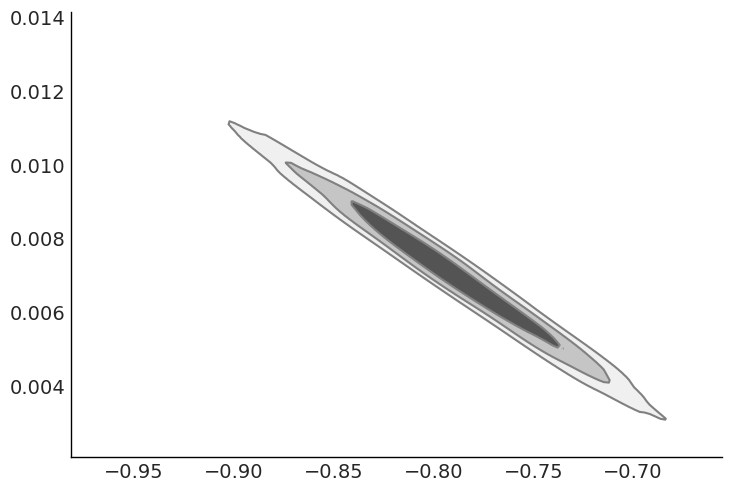

In [89]:
# パラメータw_0とw_1の事後分布の等高線プロットによる可視化
az.plot_kde(
    az.extract(trace, var_names="w_0"),
    az.extract(trace, var_names="w_1"),
    contourf_kwargs={"cmap": "Grays"}
)

横軸が`w_0`、縦軸が`w_1`を表しています。事後分布が斜めに偏在しており、両パラメータ間に強い相関があることがわかります（[後述]()しますが、パラメータ$w_0$と$w_1$は直線$w_1=-\frac{1}{26.2} (w_0-(-0.792))+0.007$上に並ぶような相関関係を持ちます）。

#### パラメータの識別可能性とデータの中心化による対処

このような**事後分布の強い相関関係**は、8.4節の収束しない場合の対処で述べた**パラメータの識別可能性**がない（識別不可能である）ことを示唆することがあります。パラメータの識別可能性とは、モデルが異なるパラメータ値をとるときに、異なる確率分布を生成できる性質を指します。よってパラメータが識別不可能であることは、**複数の異なるパラメータの組み合わせが同じモデルを表現できてしまう、冗長な状態**を表します。

詳しくは[後述]()しますが、二項ロジスティック回帰においては真のパラメータ$(w_0,w_1)$とは異なる$(w_0',w_1')$であっても、

$w_1'=-\frac{1}{\bar{x}}(w_0'-w_0)+w_1$

という関係を満たす限り、

このように、、データを中心化（標本平均$\hat{\mu}$で引く）

$x$を中心化したデータを$\tilde{x}=x-\hat{\mu}$と表すと、中心化したデータに対する二項ロジスティック回帰は以下のように定義できます。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\eta=\tilde{w_1} \tilde{x}+\tilde{w_0}  \nonumber \\
&\rm{logit}(\mu)=\eta  \nonumber \\
&p(y \mid n, \tilde{x}, \tilde{w_1}, \tilde{w_0}) = Bi(n,\mu)
\end{align}
" />

中心化前の式$\eta=w_1 x+w_0$と中心化後の式$\eta=\tilde{w_1} \tilde{x}+\tilde{w_0}$、$\tilde{x}=x-\hat{\mu}$を組み合わせると、$w_1 x+w_0=\tilde{w_1} x + \tilde{w_0}-\tilde{w_1}\hat{\mu}$という関係式が得られるので、ここから

- 中心化後のモデルで推定される$\tilde{w_0}=$中心化前のモデルで推定される$w_0+w_1\hat{\mu}$
- 中心化後のモデルで推定される$\tilde{w_1}=$中心化前のモデルで推定される$w_1$（$w_1$は中心化前後で変化なし）

となることが予測されます。

また、式の意味自体は中心化前と等価なので、正しく事後分布を推定できれば得られる予測分布は中心化前後で等しくなります。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0_c, w_1_c]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w_0_c,-0.607,0.007,-0.619,-0.593,0.0,0.0,3623.639,2402.097,1.000
w_1_c,0.007,0.002,0.004,0.010,0.0,0.0,3592.900,3061.043,1.001


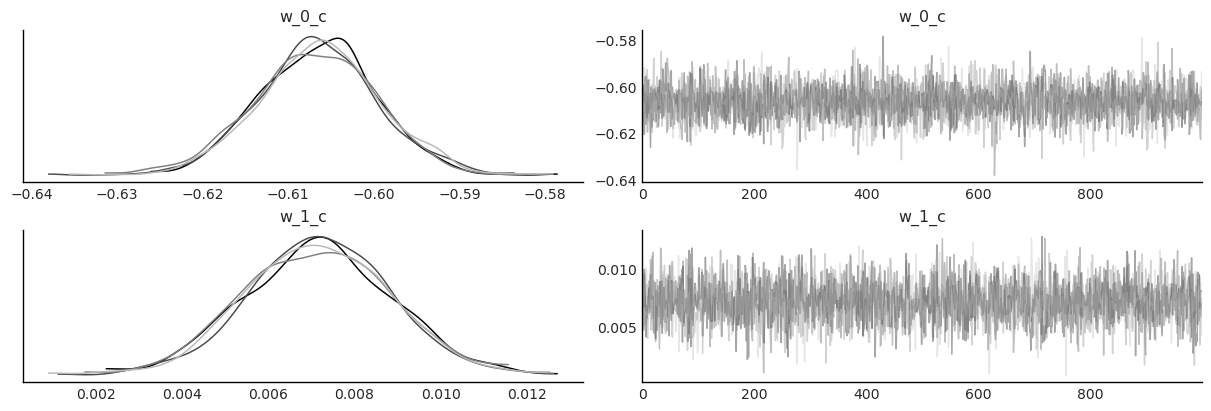

In [90]:
# 中心化してMCMCを再実行
x_mean = x_train.mean()

# モデル定義用のインスタンスを作成
binomial_regression_model = pm.Model()
# モデル式を記述
with binomial_regression_model:
    # 中心化した説明変数x_cと試行数nを観測値として定義
    x_c = pm.Data("x", x_train - x_mean, dims="record")
    n = pm.Data("n", n_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0_c = pm.Normal("w_0_c", mu=0, sigma=100)  # 中心化後のパラメータであることを明示的に示すため名前変更
    w_1_c = pm.Normal("w_1_c", mu=0, sigma=100)
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0_c + w_1_c*x_c  # 中心化した説明変数を渡す
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.invlogit(rho)
    # 確率分布
    y = pm.Binomial("y", n=n, p=mu, observed=y_train, dims="record")

# MCMCの実行（学習）
with binomial_regression_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3)

中心化する前と比べてサンプリング速度が速くなり、また`r_hat`や`ess_bulk`のような収束を表す指標も軒並み向上しています。

また、推定されたパラメータは先ほど述べた以下の関係を満たしており、中心化前後の推定されたモデルはほぼ等価であるとみなせそうです。

- 中心化後の$\tilde{w_1}$（式中の`w_1_c`）=中心化前の$w_1$
- 中心化後の$\tilde{w_0}$（式中の`w_0_c`）=中心化前の$w_0+w_1\hat{\mu}$（参考までに、$\hat{\mu}\simeq 26.2$）

<Axes: xlabel='AGE (x)', ylabel='$\\mu$'>

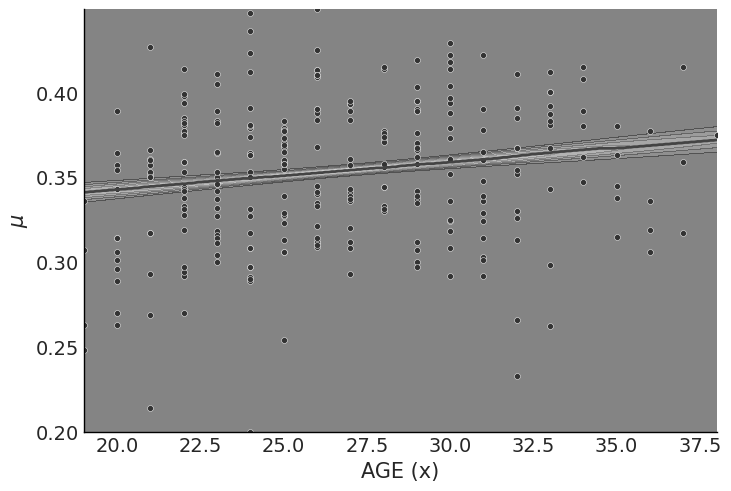

In [91]:
# 中心化したx_grid
x_grid_c = x_grid - x_mean

# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = trace.posterior["w_0_c"] + trace.posterior["w_1_c"]*xr.DataArray(x_grid_c, dims=["record"])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = 1 / (1+np.exp(-rho_posterior))
# xの値ごとにmuの事後分布の確率密度関数を計算
pdf_all_grid = []
map_grid = []  # MAP推定値
for x_idx, x_i in enumerate(x_grid_c):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # KDEでmuの事後分布分布の確率密度関数を計算
    kernel = stats.gaussian_kde(mu_posterior_i.ravel())
    pdf_i = kernel(mu_grid)  # 確率密度
    map_i = mu_grid[np.argmax(pdf_i)]
    # データを保持
    pdf_all_grid.append(pdf_i)
    map_grid.append(map_i)
pdf_grid_pivot = np.array(pdf_all_grid).T
# 確率密度をプロット
plt.contourf(X, MU, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)
plt.plot(x_grid, map_grid, color='#444444', lw=2)
plt.xlabel('AGE (x)')
plt.ylabel(r'$\mu$')
###### 学習データを散布図で描画 ######
sns.scatterplot(data=df_train_a100over,
                x='AGE', y='FG3_PCT',
                c='#333333', s=18, marker="o")

得られた事後分布自体は、中心化前とほぼ一致していることがわかります。

<Axes: >

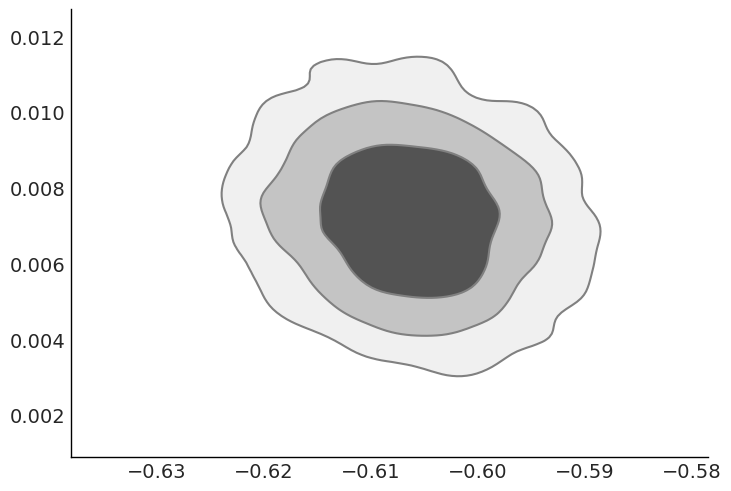

In [92]:
# パラメータw_0とw_1の事後分布の等高線プロットによる可視化
az.plot_kde(
    az.extract(trace, var_names="w_0_c"),
    az.extract(trace, var_names="w_1_c"),
    contourf_kwargs={"cmap": "Grays"}
)

パラメータ間の相関緩和が解消されたことが分かります。これはパラメータ$\tilde{w_0}$と$\tilde{w_1}$が識別可能となったことを示唆しており、これが`r_hat`や`ess_bulk`のような収束性の向上に寄与したと考えられます。

今回のケースでは中心化前のモデルでも得られる事後分布自体にほぼ変化はなく、また収束関係の指標やMCMCの所要時間もそこまで悪くはないので、中心化前のモデルをそのまま使用しても問題はなさそうです。とはいえより複雑なモデルになるとパラメータの識別可能性の悪さに起因して収束自体しなくなることもあるので、その際の改善テクニックとして中心化や標準化を覚えておいても良いでしょう。



In [93]:
print(x_mean)

26.19964349376114


#### 参考：二項ロジスティック回帰における識別可能性低下の発生メカニズムと、中心化により改善する理由

二項ロジスティック回帰においてパラメータの識別可能性が下がるメカニズムと、それが中心化により改善される理由を、図を交えて解説します。

##### 二項ロジスティック回帰の各パラメータの意味

まず、二項ロジスティック回帰において各パラメータ（切片$w_0$、傾き$w_1$、および中心化後のモデルにおける切片$\tilde{w_0}$）の意味を図で確認してみましょう。

バスケットボールの例は成功確率の変化が小さくて挙動がわかりづらいので、新たにデータを生成します。
先ほどのバスケットボールの例とオーダーが近くなるよう、平均（コード中の`X_MEAN`）26から$\pm 8$の範囲で一様に変化する説明変数$x$データを生成し、同様に試行数$n$データを$[20,600]$の範囲で生成します。

これに対して二項ロジスティック回帰の傾きパラメータ$\tilde{w_1}=w_1$（コード中の`w_1`）を`[0.05, 0.2, 0.8]`、中心化後の切片パラメータ$\tilde{w_0}$を`[-1.5, 0, 1.5]`（コード中の`w_0_c`）の範囲で変化させて応答変数$y$を生成します（中心化前の切片パラメータ$w_0$は従属的に変化する）。ここで定めた$\tilde{w_1}$や$\tilde{w_0}$（$w_0$）が、モデルの真のパラメータに相当します。

これを以下のように横軸に説明変数$x$、縦軸に見かけの成功確率$\frac{y}{n}$をプロットしてみます。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_20286/1123336127.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


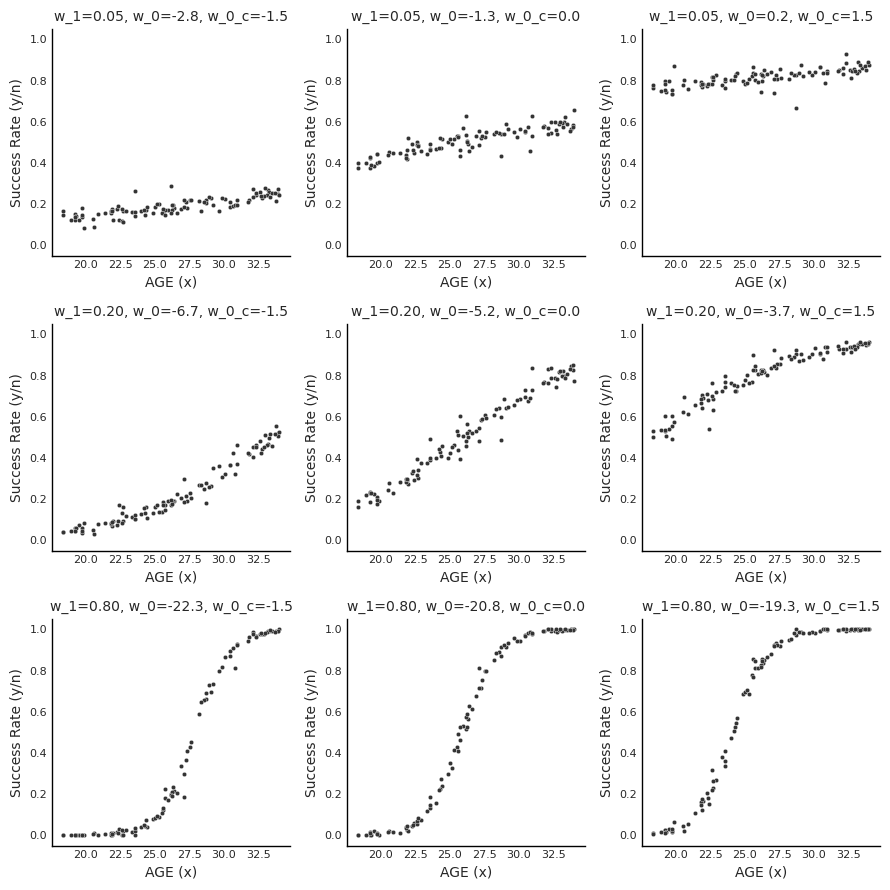

In [137]:
# データの生成
X_MEAN = 26  # 説明変数xの平均値
x = np.random.uniform(X_MEAN - 8, X_MEAN + 8, size=100)  # 説明変数データ
n = np.random.randint(20, 600, size=100)  # 試行数データ
W_1 = [0.05, 0.2, 0.8]  # 傾き（中心化前後で変化しない）
W_0_C = [-1.5, 0, 1.5]  # 中心化後の切片
fig, axes = plt.subplots(len(W_0_C), len(W_1), figsize=(len(W_1)*3, len(W_0_C)*3), squeeze=False)
for i, w_0_c in enumerate(W_0_C):
    for j, w_1 in enumerate(W_1):
        w_0 = w_0_c - w_1*X_MEAN  # 中心化前の切片に変換
        mu = 1/(1+np.exp(-(w_0 + w_1*x)))  # 成功確率（説明変数の線形結合をロジスティック変換）
        y = np.random.binomial(n=n, p=mu, size=100)
        sns.scatterplot(x=x, y=y/n, s=10, color='#333333',
                        ax=axes[j, i])
        axes[j, i].set_title(f'w_1={w_1:.2f}, w_0={w_0:.1f}, w_0_c={w_0_c:.1f}', fontsize=10)
        axes[j, i].set_xlabel('AGE (x)', fontsize=10)
        axes[j, i].set_ylabel('Success Rate (y/n)', fontsize=10)
        axes[j, i].set_ylim(-0.05, 1.05)
        axes[j, i].tick_params(axis='both', which='major', labelsize=8)
plt.tight_layout()

図を見るとわかるように、傾きパラメータ$w_1$は、文字通り説明変数$x$の変化に対する成功確率$\mu$の変化の傾きを表すことが分かります。$w_1$が大きいほど、$x$の変化に対して$\mu$が急激に変化します。

これに対し切片パラメータ$\tilde{w_0}$および$w_0$は、傾きを変化させる中心位置の$x$軸方向のずれ（すなわち平行移動）を表すことが分かります。例えば$\tilde{w_0}=0$であれば、傾きを変化させる際の中心位置とデータ平均$\bar{x}$が一致します。

> 余談となりますが、**中心化した**$\tilde{w_0}$は、データの平均値での対数オッズ$\log\frac{p}{1-p}$を表しており、$\frac{1}{1+e^{-\tilde{w_0}}}$がデータ平均での成功確率$p$、すなわち「**平均的にはこれくらいの確率で成功する**」という直感的な解釈を引き出すことができます。例えば先ほどのバスケットボールの例での$\tilde{w_0}=-0.607$は$\frac{1}{1+e^{0.607}}=0.353$より、「平均年齢の平均的な選手のスリーポイントシュート成功率は$35.3\%$」という解釈が得られます。
> 一方で中心化されていない$w_0$は「$x=0$のときこれくらいの確率で成功する」というやや直感性に欠ける意味を持ち、例えば先ほどのバスケットボールの例では、「0歳の平均的な選手のスリーポイントシュート成功率」を意味することとなります。
> このように、**データの中心化はパラメータの説明可能性の向上にも寄与する**ことが分かります。

##### 識別可能性低下の発生メカニズム

本題のパラメータの識別可能性に戻ります。二項ロジスティック回帰の式に基づくと、各データ$i$の線形予測子は以下のように表せます。

$\eta^{(i)}=w_1 x^{(i)}+w_0 \quad (8.5.1)$

このとき、真のパラメータ$(w_0,w_1)$に対して、データが母平均$\bar{x}$（本来は$\mu$と表記したいが、成功確率$\mu$と紛らわしいため$\bar{x}$と表記）付近に多く存在することを考えると、他のパラメータの組み合わせ$(w_0',w_1')$であっても、以下の関係を満たす限りは似たような$\eta^{(i)}$が求められてしまいます。

$w_1'=-\frac{1}{\bar{x}}(w_0'-w_0)+w_1 \quad (8.5.2)$

これは、$x^{(i)}\simeq \bar{x}$のとき、式$(8.5.2)$を変形して式$(8.5.1)$を代入すると

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
w_1' x^{(i)}+w_0'
&=w_1x^{(i)}-\frac{x^{(i)}}{\bar{x}}(w_0'-w_0)+w_0' \\
&\simeq w_1x^{(i)}-(w_0'-w_0)+w_0' \\
&=w_1x^{(i)}+w_0 \\
&=\eta^{(i)}
\end{align}
" />

となることから確認できます。似たような$\eta$が求められるということは、そこから求められる$\mu$や応答変数$y$の分布も似たようなものとなるため、異なるパラメータの組み合わせがほぼ同じモデルを表現できてしまう、すなわち**識別不可能に近い状態**となってしまいます。

例えば、すぐ上でプロットした左上の図に相当する、真の$w_1=0.05$、真の$w_0=-2.8$（$\tilde{w_0}=-1.5$）のケースを考えると、$w_1'=\frac{1}{26}(w_0'+2.8)-0.05$を満たす限り、真のモデルとほぼ同じモデルを表現できます。
この条件を満たす$(w_0',w_1')=(-1.8,0.012),(-2.3, 0.031),(-3.3,0.069),(-3.8,0.088)$から予測される$\mu$を、データを表す散布図上にプロットしてみます。

Alternative w_0: -1.8, w_1: 0.011538461538461553
Alternative w_0: -2.3, w_1: 0.03076923076923077
Alternative w_0: -3.3, w_1: 0.06923076923076923
Alternative w_0: -3.8, w_1: 0.08846153846153847


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_20286/3998347158.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


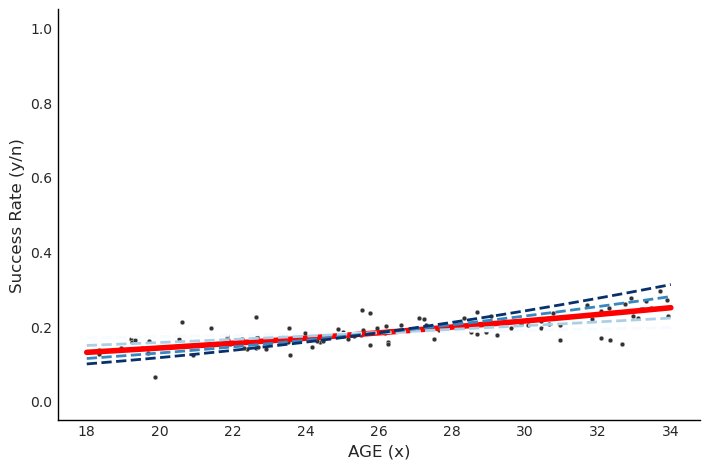

In [138]:
# データの生成
W_1 = 0.05  # 真の傾きパラメータ
W_0 = -2.8  # 真の切片パラメータ
mu = 1/(1+np.exp(-(W_0 + W_1*x)))  # 成功確率（説明変数の線形結合をロジスティック変換）
y = np.random.binomial(n=n, p=mu, size=100)
# データを散布図でプロット
sns.scatterplot(x=x, y=y/n, s=12, color='#333333')
plt.xlabel('AGE (x)', fontsize=12)
plt.ylabel('Success Rate (y/n)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
# 真のパラメータによるロジスティック回帰直線
x_line = np.linspace(X_MEAN - 8, X_MEAN + 8, 200)
mu_line = 1/(1+np.exp(-(W_0 + W_1*x_line)))
plt.plot(x_line, mu_line, color='red', lw=4)
# 真値（w_0=-2.8,w_1=0.05）と識別困難なパラメータを関係式に基づき選択
W_0_ALT = [-1.8, -2.3, -3.3, -3.8]
color_map = plt.get_cmap('Blues', len(W_0_ALT))
for i, w_0_alt in enumerate(W_0_ALT):
    w_1_alt = -(w_0_alt - W_0) / X_MEAN + W_1  # 関係を満たすw_1を計算
    print(f'Alternative w_0: {w_0_alt}, w_1: {w_1_alt}')
    mu_alt = 1/(1+np.exp(-(w_0_alt + w_1_alt*x_line)))
    plt.plot(x_line, mu_alt, lw=2, ls='--', color=color_map(i))  # カラーマップに従いプロット

赤い線が真のパラメータから予測される$\mu$を表しており、他の青い線が条件を満たす他のパラメータから予測される$\mu$を表します。

この関係を満たす限り、パラメータが変化してもデータ平均を中心に傾きが変化するだけなので、予測される$y$の値と実際のデータとの差は大きくなりません（特に、平均付近にデータが集中するケースでこの傾向は顕著です）。
これが二項ロジスティック回帰においてパラメータのメカニズムです。

先ほどデータを中心化せずに求めた事後分布で$w_1=-\frac{1}{26.2} (w_0-(-0.792))+0.007$という相関関係が見られたのも、まさに

$w_1'=-\frac{1}{\bar{x}}(w_0'-w_0)+w_1$

という関係を満たす$w_0',w_1'$が、真値からある程度外れていてもデータにフィットしてしまうがために発生してしまった現象です。

##### 中心化により識別可能性が向上する理由

中心化を行うと、中心化後の説明変数$\tilde{x}$は

$\tilde{x}^{(i)}=x^{(i)}-\hat{\mu}$

となります。これを式$(8.5.1)$に代入すると

$\eta^{(i)}=w_1 (\tilde{x}^{(i)}+\hat{\mu})+w_0 = w_1\tilde{x}^{(i)} + (w_0+w_1\hat{\mu})$

となります。よって中心化後のパラメータの真値$\tilde{w_0},\tilde{w_1}$は、中心化前のパラメータの真値$w_0,w_1$に対して

$\tilde{w_0}=w_0+w_1\hat{\mu},\tilde{w_1}=w_1 \quad (8.5.4)$

の関係を持ちます。この中心化後のパラメータの真値に対し、識別困難なパラメータ$\tilde{w_0}',\tilde{w_1}'$が満たす関係を、式$(8.5.2)$と同様の考え方で中心化後の母平均が$\bar{x}-\hat{\mu}$となることも考慮して求めると、

$\tilde{w_1}'=-\frac{1}{\bar{x}-\hat{\mu}}(\tilde{w_0}'-\tilde{w_0})+\tilde{w_1} \quad (8.5.5)$

この式中の$\bar{x}-\hat{\mu}$は非常に小さな値をとるため、式$(8.5.4)$中の$\tilde{w_0}'$が少し変化するだけでも、識別困難となる関係を満たす$\tilde{w_1}'$の値が急激に変化します。これにより線形予測子の傾きも大きく変化するため、モデルがデータにすぐにフィットしなくなり、同じモデルを表現できる冗長なパラメータの範囲を、真値周辺の狭い範囲に限定できます。これが中心化によりパラメータの識別可能性を改善できる理由です。

Centerized true parameters: w_0_c=-1.4777746716223594, w_1_c=0.05, x_mean=26.444506567552807
Alternative w_0_c: -0.47777467162235965, w_1_c: 2.299685545717388
Alternative w_0_c: -0.9777746716223594, w_1_c: 1.1748427728586943
Alternative w_0_c: -1.9777746716223594, w_1_c: -1.0748427728586942
Alternative w_0_c: -2.4777746716223596, w_1_c: -2.199685545717389


/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_20286/1317600784.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


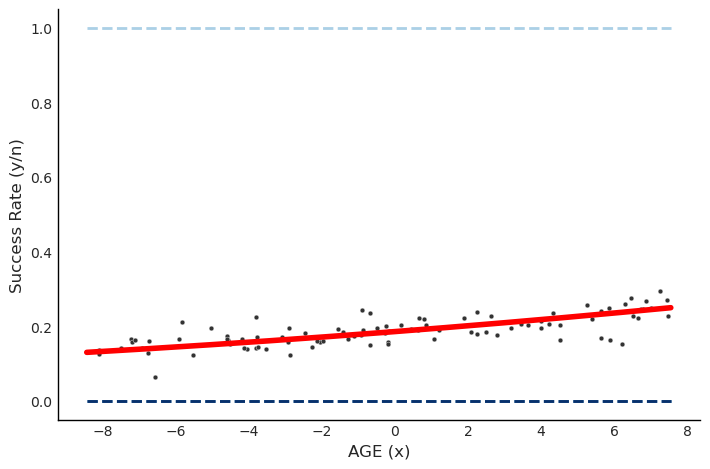

In [139]:
# データを中心化
x_mean = x.mean()  # データの平均
x_c = x - x_mean
# 中心化後のパラメータの真値（式8.5.4に基づく）
w_0_c = W_0 + W_1 * x_mean  # 中心化後の切片パラメータの真値
w_1_c = W_1  # 中心化後の傾きパラメータの真値
print(f'Centerized true parameters: w_0_c={w_0_c}, w_1_c={w_1_c}, x_mean={x_mean}')
# データを散布図でプロット
sns.scatterplot(x=x_c, y=y/n, s=12, color='#333333')
plt.xlabel('AGE (x)', fontsize=12)
plt.ylabel('Success Rate (y/n)', fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
# 真のパラメータによるロジスティック回帰直線（中心化後）
x_line_c = np.linspace(X_MEAN - x_mean - 8, X_MEAN - x_mean + 8, 200)
mu_line = 1/(1+np.exp(-(w_0_c + w_1_c*x_line_c)))
plt.plot(x_line_c, mu_line, color='red', lw=4)
# 真値（w_0_c,w_1_c）と識別困難なパラメータを選択
W_0_ALT = [-1.8, -2.3, -3.3, -3.8]  # 中心化前の切片の候補をそのまま使用（中心化前後で結果を比較するため）
color_map = plt.get_cmap('Blues', len(W_0_ALT))
for i, w_0_alt in enumerate(W_0_ALT):
    w_0_alt_c = w_0_alt + W_1 * x_mean  # 中心化後の切片に変換
    w_1_alt_c = -(w_0_alt_c - w_0_c) / (X_MEAN - x_mean) + w_1_c  # 関係式からw_1に変換
    print(f'Alternative w_0_c: {w_0_alt_c}, w_1_c: {w_1_alt_c}')
    mu_alt = 1/(1+np.exp(-(w_0_alt_c + w_1_alt_c*x_line)))
    plt.plot(x_line_c, mu_alt, lw=2, ls='--', color=color_map(i))  # カラーマップに従いプロット